# **Predicting Road Accident Risk**

## **🏆 Competition information**

**Aim**. Build a machine learning model that predicts the road accident risk.

**Dataset**. The dataset provides information about road conditions, traffic signs, weather, lighting, and other contextual factors. 

**Problem type**. This problem is a regression task, evaluated using the Root Mean Squared Error (RMSE) metric.

**Citation**:

* Walter Reade and Elizabeth Park. Predicting Road Accident Risk. https://kaggle.com/competitions/playground-series-s5e10, 2025. Kaggle.


**-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------**


## **📒 Notebook information**

**Objective**. The goal of this notebook is to be as clear and explanatory as possible while addressing the main objective of the competition. Each step is thoroughly explained to ensure full transparency in the reasoning, feature selection, and modeling process.

**Structure**. This notebook is organized into the following sections:

📚1. **Libraries**

📂2. **Data loading and Preparation**. Importing and inspecting the datasets and preparing variables for analysis.
      
🔎3. **Exploratory Data Analysis (EDA)**. Includes a global overview, analysis of the target variable, feature-by-feature inspection, and interaction exploration. Additionally, we check for possible data drift between the training and test datasets.  
    
🔧4. **Feature Engineering**. Preparing and transforming variables for the different models.  

✂️5. **Train–Validation Split**. Dividing the training data into separate sets for model evaluation.  

🧠6. **Models Training**. Testing multiple algorithms (Linear Regression, Random Forest, and XGBoost), both with all variables and with selected interaction features.  

📊 7. **Results Comparison**. Evaluating model performance using RMSE and selecting the best configuration.

🚀 8. **Final Prediction and Submission Preparation**. Training the final model on the full dataset and generating the Kaggle submission file.


## **📚 1. Libraries**

In [54]:
## Basic Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
import os

# Statistical Analysis
from scipy.stats import ks_2samp, chi2_contingency

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor

# Silence unnecessary warnings for cleaner output
warnings.filterwarnings("ignore")

## **📂 2. Data Loading and Preparation**

Import the  datasets (`train` and `test`) and perform initial preparation steps.  

The training dataset contains both features and the target variable (`accident_risk`), while the test dataset includes only the features.  

We remove the `id` column and separate the target variable from the predictors to prepare the data for modeling.

In [55]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/playground-series-s5e10/sample_submission.csv
/kaggle/input/playground-series-s5e10/train.csv
/kaggle/input/playground-series-s5e10/test.csv


In [56]:
# Directories
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        
# Load data
train_raw = pd.read_csv("/kaggle/input/playground-series-s5e10/train.csv")
test_raw = pd.read_csv("/kaggle/input/playground-series-s5e10/test.csv")

# Display the first few rows of the training data
train_raw.head()

/kaggle/input/playground-series-s5e10/sample_submission.csv
/kaggle/input/playground-series-s5e10/train.csv
/kaggle/input/playground-series-s5e10/test.csv


,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [57]:
# Split features and target
X_train = train_raw.drop(columns=["accident_risk", "id"])
y_train = train_raw["accident_risk"]

# Prepare the test set (drop id)
X_test = test_raw.drop(columns=["id"])

## **🔎 3. Exploratory Data Analysis (EDA)**

In this section we are going to explore our dataset before applying any machine learning model. The aim is identify patterns, correlations, and potential inconsistencies.

We analize:

* A. Global overview.
* B. Target distribution.
* C. Numerical variables.
* D. Categorical variables.
* E. Boolean features.
* F. Festures interactions.
* G. Data drift.

### **A. Global overview**

The **aim** of this section is make a quick inspection of the dataset: structure, data types, and null values. We also split features from target.  

#### **Conclusions**:

The dataset contains 517,754 rows and 14 columns, with no missing values detected.  

We classify variables into three main groups:

* **Numerical**: num_lanes, curvature, speed_limit, num_reported_accidents
* **Categorical**: road_type, lighting, weather, time_of_day 
* **Booleans**: road_signs_present, public_road, holiday, school_season

In [58]:
# Basic dataset structure
train_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   road_type               517754 non-null  object 
 2   num_lanes               517754 non-null  int64  
 3   curvature               517754 non-null  float64
 4   speed_limit             517754 non-null  int64  
 5   lighting                517754 non-null  object 
 6   weather                 517754 non-null  object 
 7   road_signs_present      517754 non-null  bool   
 8   public_road             517754 non-null  bool   
 9   time_of_day             517754 non-null  object 
 10  holiday                 517754 non-null  bool   
 11  school_season           517754 non-null  bool   
 12  num_reported_accidents  517754 non-null  int64  
 13  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(

In [59]:
# Columns by datatype
num_cols = ["num_lanes", "curvature", "speed_limit", "num_reported_accidents"]
cat_cols = ["road_type", "lighting", "weather", "time_of_day"]
bool_cols = ["road_signs_present", "public_road", "holiday", "school_season"]

# Target
target = "accident_risk"

### **B. Target distribution**

In this subsection we analyze the distribution of the target variable (`accident_risk`) in order to determine whether any transformation is required. 

We perform the following steps:

* Compute descriptive statistics.
* Visualize the distribution.
* Check for skewness and outliers.

#### **Conclusions**

The target variable is bounded between 0.0 and 1.0, with a mean of 0.35 (std = 0.166). Fifty percent of the cases fall between 0.23 and 0.46.

The distribution is slightly right-skewed, with fewer cases showing high-risk levels above 0.7.

The boxplot confirms a concentration of values around the central range (0.2–0.5), while a small number of outliers appear near the upper tail (≥ 0.8). However, these outliers are expected, as they represent genuine high-risk situations. We choose to keep them in the dataset (no transformation or removal) to preserve their impact on model learning.

In [60]:
# Summary statistics
train_raw[target].describe()

count    517754.000000
mean          0.352377
std           0.166417
min           0.000000
25%           0.230000
50%           0.340000
75%           0.460000
max           1.000000
Name: accident_risk, dtype: float64

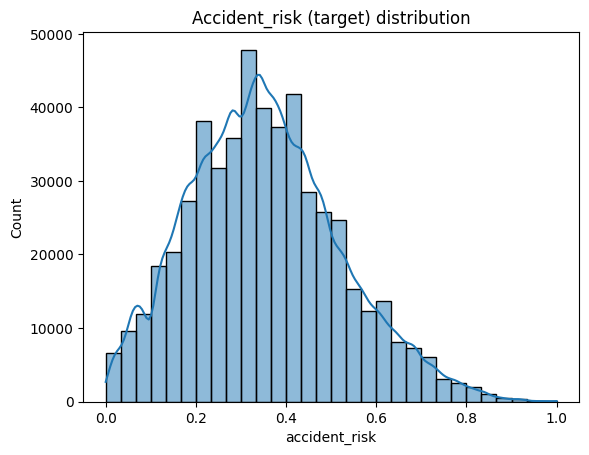

In [61]:
# Target Distribution
sns.histplot(train_raw[target], bins=30, kde=True)
plt.title("Accident_risk (target) distribution")
plt.show()

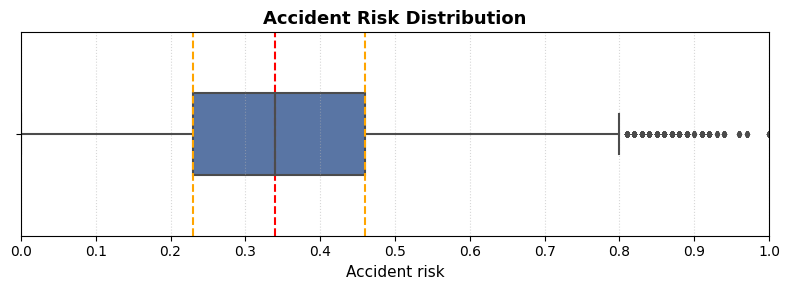

In [62]:
# Skewness or outliers (boxplot)
plt.figure(figsize=(8, 3))
sns.boxplot(
    x=train_raw[target],
    color="#4C72B0",
    width=0.4,
    fliersize=3
)

# Percentiles
q25 = train_raw[target].quantile(0.25)
q50 = train_raw[target].quantile(0.50)
q75 = train_raw[target].quantile(0.75)

# Add vertical lines
plt.axvline(q25, color="orange", linestyle="--", linewidth=1.5)
plt.axvline(q50, color="red", linestyle="--", linewidth=1.5)
plt.axvline(q75, color="orange", linestyle="--", linewidth=1.5)

# Axis and layout
plt.title("Accident Risk Distribution", fontsize=13, weight="bold")
plt.xlabel("Accident risk", fontsize=11)
plt.xlim(0, 1)
plt.xticks(np.arange(0, 1.10, 0.10)) 
plt.grid(axis="x", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

### **C. Numerical variables**

In this section, we explore the numerical variables to understand their distributions, detect potential outliers, and analyze correlations with the target variable `accident_risk`.

#### **Conclusions**

After inspecting the **distributions** (histograms), we see that `num_lanes` and `speed_limit` behave as ordinal features. For that reason, we will move them to the categorical section (`cat_cols`). Therefore, we will analyze them in the *3.D. Categorical Variables* section and later transform them appropriately during *4. Feature Engineering*.

Regarding `num_reported_accidents`, a transformation might be required when using linear models to reduce skewness.

No significant **outliers** are detected in `curvature`. For `num_reported_accidents`, a few outliers are visible, but they appear to represent real high-risk situations (areas with repeated incidents). Thus, these data points are retained as they provide meaningful information.

Regarding the **correlations**, `curvature` shows a strong positive correlation with the target variable `accident_risk`. On the other hand, `num_reported_accidents` exhibits a moderate positive correlation. The correlation between both features is low, indicating no collinearity issues.

Regardin **statistics**:

* `curvature` has a mean of 0.49 and a standard deviation of 0.272, suggesting that most roads exhibit moderate curvature. This variable is normalized within the range 0–1. 
* `num_reported_accidents` has a mean of 1.19 and a standard deviation close to 1. Fifty percent of the observations fall between 1 and 2 reported accidents.

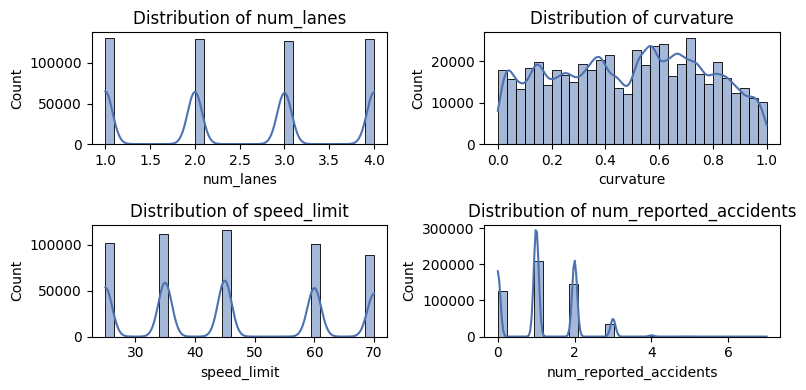

In [63]:
# Distribution (histogram)

fig, axes = plt.subplots(2, 2, figsize=(8, 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(train_raw[col], bins=30, kde=True, ax=axes[i], color="#4C72B0")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [64]:
# Reassign variable types: num_lanes and speed_limit as categorical
num_cols = [col for col in num_cols if col not in ["num_lanes", "speed_limit"]]
cat_cols.extend(["num_lanes", "speed_limit"])

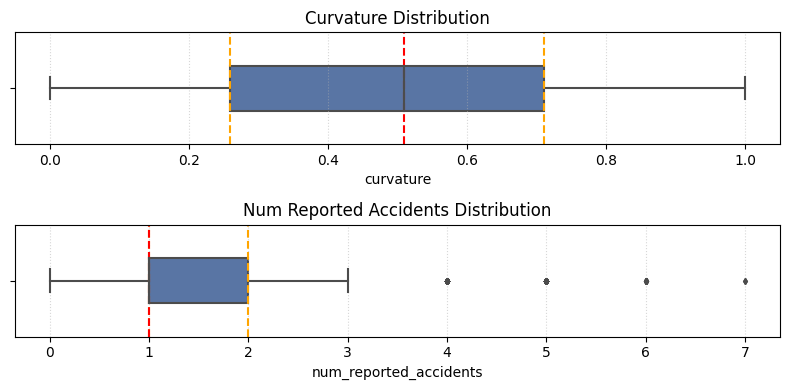

In [65]:
# Boxplot and outliers

fig, axes = plt.subplots(2, 1, figsize=(8, 4))

# Curvature 
sns.boxplot(
    x=train_raw["curvature"],
    color="#4C72B0",
    width=0.4,
    fliersize=3,
    ax=axes[0]
)
q25 = train_raw["curvature"].quantile(0.25)
q50 = train_raw["curvature"].quantile(0.50)
q75 = train_raw["curvature"].quantile(0.75)

axes[0].axvline(q25, color="orange", linestyle="--", linewidth=1.5)
axes[0].axvline(q50, color="red", linestyle="--", linewidth=1.5)
axes[0].axvline(q75, color="orange", linestyle="--", linewidth=1.5)
axes[0].set_title("Curvature Distribution")
axes[0].set_xlabel("curvature")
axes[0].grid(axis="x", linestyle=":", alpha=0.5)

# Num Reported Accidents
sns.boxplot(
    x=train_raw["num_reported_accidents"],
    color="#4C72B0",
    width=0.4,
    fliersize=3,
    ax=axes[1]
)
q25 = train_raw["num_reported_accidents"].quantile(0.25)
q50 = train_raw["num_reported_accidents"].quantile(0.50)
q75 = train_raw["num_reported_accidents"].quantile(0.75)

axes[1].axvline(q25, color="orange", linestyle="--", linewidth=1.5)
axes[1].axvline(q50, color="red", linestyle="--", linewidth=1.5)
axes[1].axvline(q75, color="orange", linestyle="--", linewidth=1.5)
axes[1].set_title("Num Reported Accidents Distribution")
axes[1].set_xlabel("num_reported_accidents")
axes[1].grid(axis="x", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

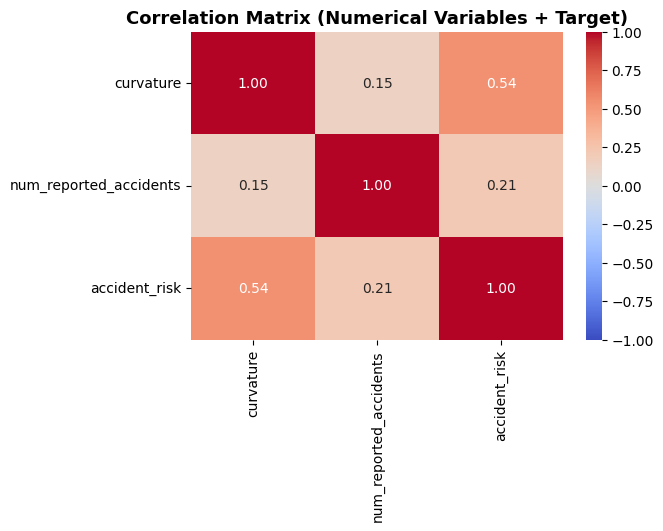

In [66]:
# Correlation between numerical features and the target
corr = train_raw[["curvature", "num_reported_accidents", target]].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix (Numerical Variables + Target)", fontsize=13, weight="bold")
plt.show()

In [67]:
# Descriptive statistics
train_raw[num_cols].describe()

,curvature,num_reported_accidents
count,517754.000000,517754.000000
mean,0.488719,1.187970
std,0.272563,0.895961
min,0.000000,0.000000
25%,0.260000,1.000000
50%,0.510000,1.000000
75%,0.710000,2.000000
max,1.000000,7.000000


### **D. Categorical variables**

In this section, we explore the categorical features and their relationship with the target variable `accident_risk`. We study the class balance for each categorical feature, the average accident risk per category and associations between categorical variables.  

#### **Conclusions**:

All categorical variables are well balanced, with no extreme label dominance.  

The relationship with the target shows that `driving at night`, under `foggy or rainy weather`, and with `higher speed limits` corresponds to increased accident risk. On the other hand, `road type`, `number of lanes`, and `time of day` show almost no variation in risk.  

Cramér’s V values ≤ 0.07 across all pairs confirm no strong association between categorical variables (no multicollinearity issues).

These insights suggest that environmental and lighting conditions are more relevant predictors of accident severity than structural road factors.

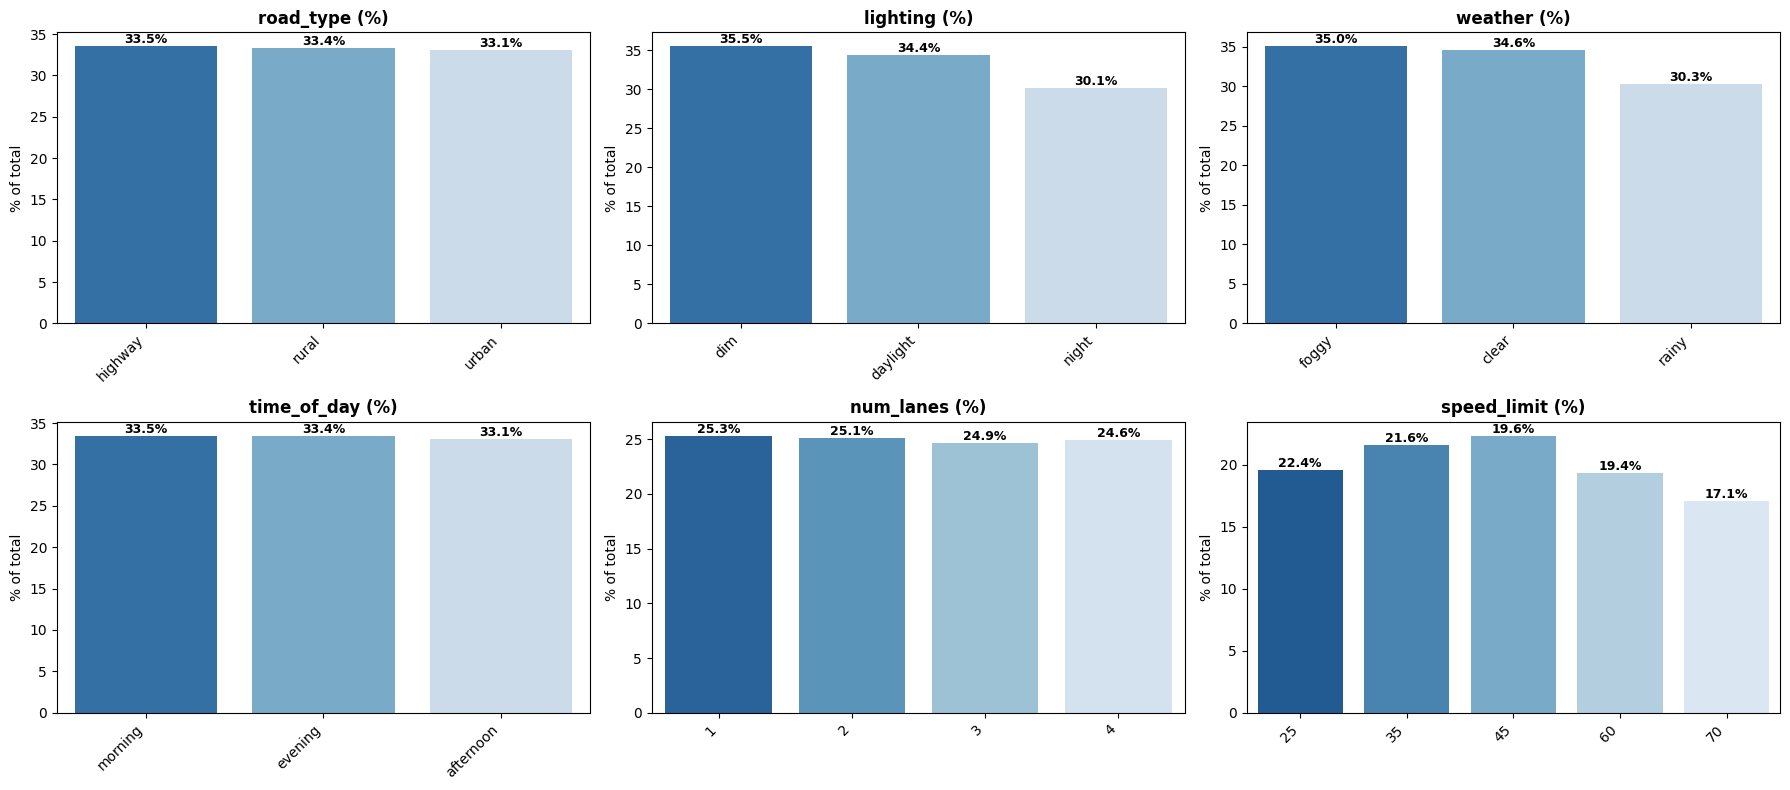

In [68]:
# Distribution for each categorical feature

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Calculate %
    counts = train_raw[col].value_counts(normalize=True).mul(100).round(2)
    order = counts.index

    # Barplot
    sns.barplot(x=counts.index, y=counts.values, ax=axes[i], palette="Blues_r")
    axes[i].set_title(f"{col} (%)", fontsize=12, weight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("% of total")
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha="right")

    # Annotations
    for p, value in zip(axes[i].patches, counts.values):
        axes[i].annotate(f"{value:.1f}%", 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='bottom', fontsize=9, color='black', weight='bold')

plt.tight_layout()
plt.show()

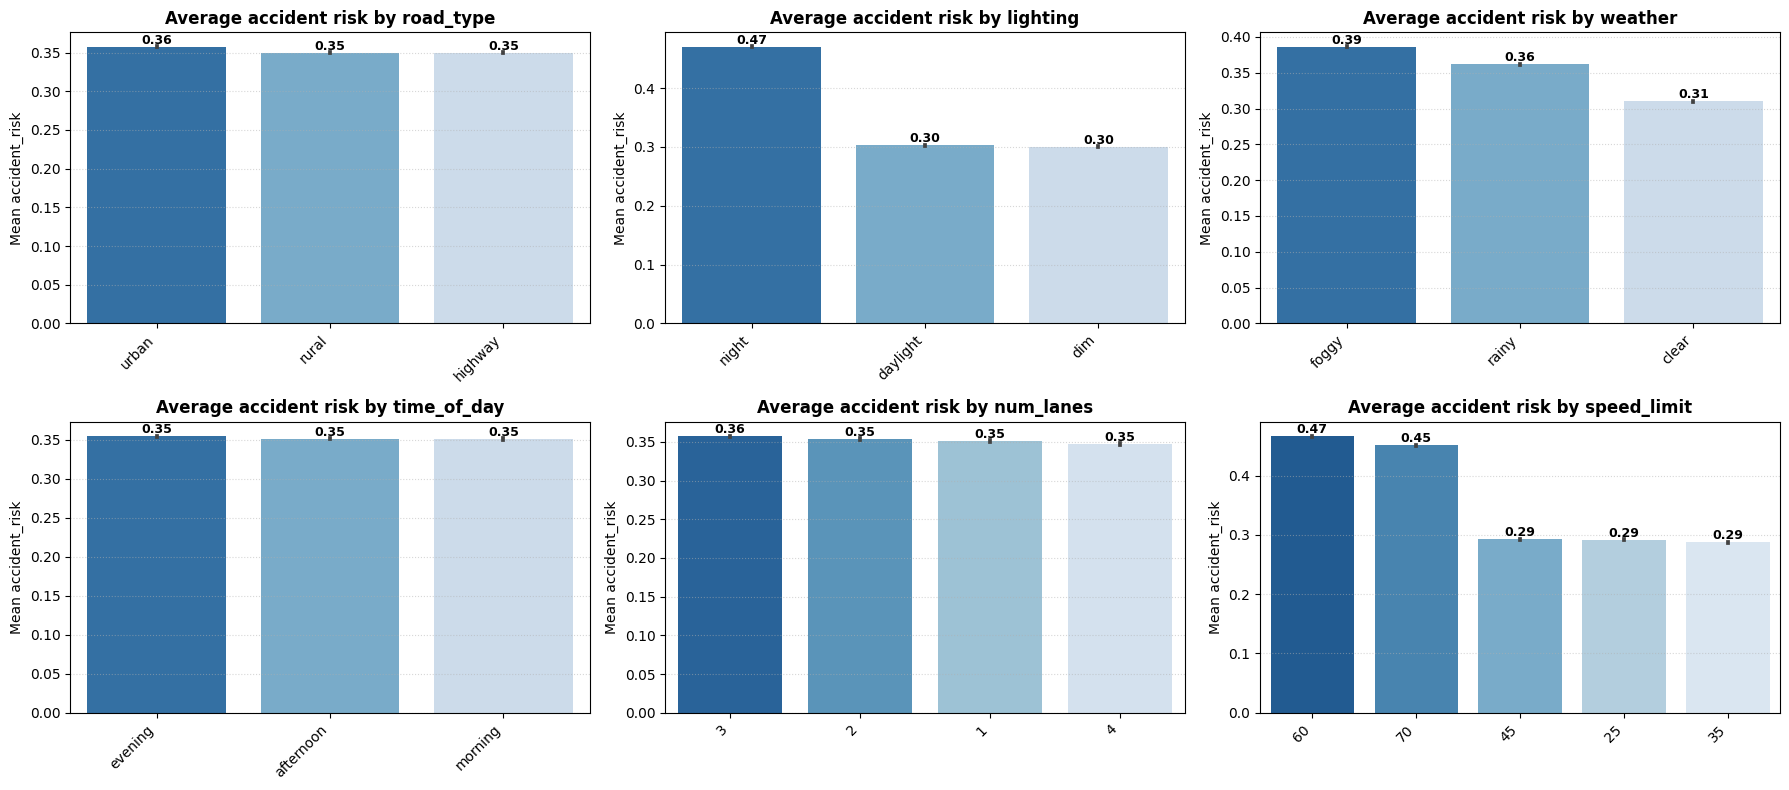

In [69]:
# Average accident risk per category
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = train_raw.groupby(col)[target].mean().sort_values(ascending=False).index
    
    # Barplot
    sns.barplot(x=col, y=target, data=train_raw, order=order,
                palette="Blues_r", estimator="mean", ax=axes[i])
    
    axes[i].set_title(f"Average accident risk by {col}", fontsize=12, weight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Mean accident_risk")
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha="right")
    axes[i].grid(axis="y", linestyle=":", alpha=0.5)

    # Anotations
    for p in axes[i].patches:
        value = p.get_height()
        axes[i].annotate(f"{value:.2f}",
                         (p.get_x() + p.get_width() / 2., value),
                         ha='center', va='bottom', fontsize=9, color='black', weight='bold')

plt.tight_layout()
plt.show()

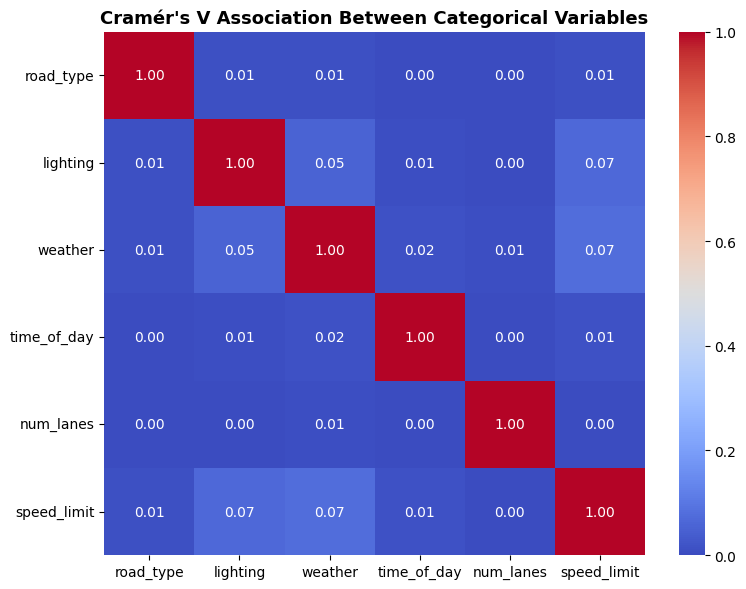

In [70]:
# Association between categorical

# Cramér's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix, correction=False)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))    
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Compute pairwise Cramér’s V for all categorical variables
cat_vars = cat_cols  
n = len(cat_vars)
cramers_results = pd.DataFrame(np.zeros((n, n)), 
                               index=cat_vars, columns=cat_vars)

for col1 in cat_vars:
    for col2 in cat_vars:
        if col1 == col2:
            cramers_results.loc[col1, col2] = 1.0
        else:
            cramers_results.loc[col1, col2] = cramers_v(train_raw[col1], train_raw[col2])

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cramers_results, annot=True, cmap="coolwarm", fmt=".2f", vmin=0, vmax=1)
plt.title("Cramér's V Association Between Categorical Variables", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()

### **E. Boolean features**

In this section, we explore the boolean variables to verify class balance and potential influence on accident risk.

#### **Conclusions**

All features are balanced, with around 50% of records in each category.  

The average accident risk remains almost identical across True and False groups for all features. Overall, boolean features add limited predictive power individually but could still enhance interactions in non-linear models like XGBoost or Random Forest. 

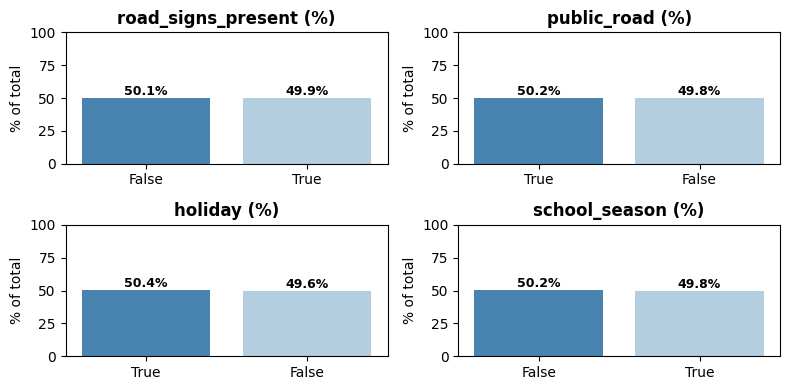

In [71]:
# Distribution of Boolean features

fig, axes = plt.subplots(2, 2, figsize=(8, 4))
axes = axes.flatten()

for i, col in enumerate(bool_cols):
    counts = train_raw[col].value_counts(normalize=True).mul(100).round(2)
    sns.barplot(x=counts.index.astype(str), y=counts.values, ax=axes[i], palette="Blues_r")
    axes[i].set_title(f"{col} (%)", fontsize=12, weight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("% of total")
    axes[i].set_ylim(0, 100)

    # Annotations
    for p, value in zip(axes[i].patches, counts.values):
        axes[i].annotate(f"{value:.1f}%", 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='bottom', fontsize=9, color='black', weight='bold')

plt.tight_layout()
plt.show()

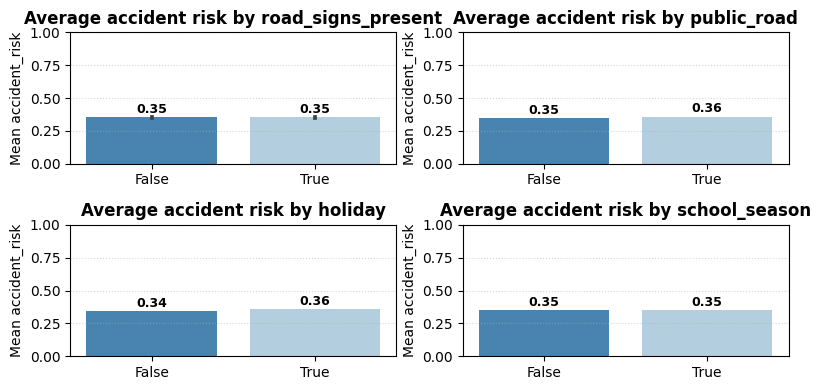

In [72]:
# Relationship between Boolean features and target variable

fig, axes = plt.subplots(2, 2, figsize=(8, 4))
axes = axes.flatten()

for i, col in enumerate(bool_cols):
    order = [False, True]
    sns.barplot(x=col, y=target, data=train_raw, order=order, palette="Blues_r", ax=axes[i])
    axes[i].set_title(f"Average accident risk by {col}", fontsize=12, weight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Mean accident_risk")
    axes[i].set_ylim(0, 1)
    axes[i].grid(axis="y", linestyle=":", alpha=0.5)

    # Compute mean risk per boolean category
    means = train_raw.groupby(col)[target].mean().to_dict()

    # Anotations
    for j, label in enumerate(order):
        val = means.get(label, np.nan)
        if not np.isnan(val):
            axes[i].annotate(f"{val:.2f}", 
                             (j, val + 0.01), 
                             ha='center', va='bottom', 
                             fontsize=9, weight='bold', color='black')

plt.tight_layout()
plt.show()

### **F. Interaction analysis**

In this section, we explore interaction features: *combinations of existing variables that might better explain accident risk*. Interactions often capture nonlinear relationships that are not visible when variables are analyzed independently.

We study three interactions:

* `curvature_speed`. Represents the combined effect of road curvature and speed.  
* `curvature_night`. Represents the combined effect of curved roads and low-light conditions.  
* `speed_rain`. Represents the combined effect of speed affects accident risk and rainy conditions.

These engineered features are tested for their correlation with the target variable `accident_risk`.

#### **Conclusions**

`curvature_speed` shows and strong positive correlation: accidents are significantly more frequent when high curvature coincides with higher speed limits. 

`curvature_night`shows a high curvature under low-light conditions substantially raises accident risk.

`speed_rain` shows a weak positive correlation. 

These results suggest that interaction effects between curvature, speed, and lighting play a major role in accident severity. 

In [73]:
# Feature Interaction Creation
train_raw["curvature_speed"] = train_raw["curvature"] * train_raw["speed_limit"]
train_raw["curvature_night"] = train_raw["curvature"] * (train_raw["lighting"] == "night").astype(int)
train_raw["speed_rain"] = train_raw["speed_limit"] * (train_raw["weather"] == "rainy").astype(int)

In [74]:
# Correlation with target variable
corrs = train_raw[["curvature_speed", "curvature_night", "speed_rain", "accident_risk"]].corr()[target].sort_values(ascending=False)
print(corrs)

accident_risk      1.000000
curvature_speed    0.675621
curvature_night    0.581813
speed_rain         0.115013
Name: accident_risk, dtype: float64


In [75]:
# Apply the same transformations to the test set
test_raw["curvature_speed"] = test_raw["curvature"] * test_raw["speed_limit"]
test_raw["curvature_night"] = test_raw["curvature"] * (test_raw["lighting"] == "night").astype(int)

### **G. Data Drift**

Before modeling, it is essential to verify that the feature distributions are consistent between the training and test datasets. Significant differences (data drift) can cause poor generalization and degraded model performance.

To detect drift, we applied:
* **Kolmogorov–Smirnov (KS) test** for numerical variables.  
* **Chi-squared test** for categorical and boolean variables.

A drift is flagged if the *p-value* < 0.05, meaning that the train and test distributions differ significantly.

#### **Conclusions**

No major data drift was detected in either numerical or categorical variables. The only minor signal appears for `road_signs_present`, but the effect is small and likely due to random variation.  
We can conclude that the competition data is stable and comparable between train and test.

In [76]:
# Preprare data
train_drift = train_raw
test_drift = test_raw

train_drift["is_train"] = 1
test_drift["is_train"] = 0

combined = pd.concat([train_drift, test_drift], ignore_index=True)

In [77]:
# Numerical values (Kolmogorov–Smirnov test)

drift_results_num = []

for col in num_cols:
    stat, pval = ks_2samp(train_raw[col], test_raw[col])
    drift_results_num.append({
        "feature": col,
        "p_value": pval,
        "drift_detected": pval < 0.05
    })

drift_num_df = pd.DataFrame(drift_results_num)
display(drift_num_df)

,feature,p_value,drift_detected
0,curvature,0.115271,False
1,num_reported_accidents,0.835574,False


In [78]:
# Categorical and boolean features (Chi-squared test)
drift_results_cat = []

for col in cat_cols + bool_cols:
    contingency = pd.crosstab(combined[col], combined["is_train"])
    stat, pval, _, _ = chi2_contingency(contingency)
    drift_results_cat.append({
        "feature": col,
        "p_value": pval,
        "drift_detected": pval < 0.05
    })

drift_cat_df = pd.DataFrame(drift_results_cat)
display(drift_cat_df)

,feature,p_value,drift_detected
0,road_type,0.662700,False
1,lighting,0.844953,False
2,weather,0.502043,False
3,time_of_day,0.967641,False
4,num_lanes,0.607593,False
5,speed_limit,0.994073,False
6,road_signs_present,0.005742,True
7,public_road,0.972835,False
8,holiday,0.341447,False
9,school_season,0.466041,False


## **🔧4. Feature Engineering**

In this section, we prepare the dataset for model training by transforming, encoding, and scaling relevant variables.

We focus on three tasks:
* **Transforming skewed variables** for better performance in linear models.  
* **Standardizing numeric** to ensure consistent scaling.
* **Encoding categorical features**. One-Hot for nominal, Ordinal for ordered variables.  

We keep all features to use them according to the model.

In [79]:
# Copy datasets
train = train_raw.copy()
test = test_raw.copy()

In [80]:
# Log transformation for "num_reported_accidents"
train["num_reported_accidents_log"] = np.log1p(train["num_reported_accidents"])
test["num_reported_accidents_log"] = np.log1p(test["num_reported_accidents"])

In [81]:
# Standardize numerical features
scaler_log = StandardScaler()
scaler_cs  = StandardScaler()
scaler_cn  = StandardScaler()

train["num_reported_accidents_log_scaled"] = scaler_log.fit_transform(train[["num_reported_accidents_log"]])
test["num_reported_accidents_log_scaled"]  = scaler_log.transform(test[["num_reported_accidents_log"]])

train["curvature_speed_scaled"] = scaler_cs.fit_transform(train[["curvature_speed"]])
test["curvature_speed_scaled"]  = scaler_cs.transform(test[["curvature_speed"]])

train["curvature_night_scaled"] = scaler_cn.fit_transform(train[["curvature_night"]])
test["curvature_night_scaled"]  = scaler_cn.transform(test[["curvature_night"]])

In [82]:
nominal_cols = ["road_type", "lighting", "weather", "time_of_day"]

# One-hot encoding
train_ohe = pd.get_dummies(train[nominal_cols], drop_first=False, prefix=nominal_cols)
test_ohe  = pd.get_dummies(test[nominal_cols], drop_first=False, prefix=nominal_cols)

# Align columns between train and test
train_ohe, test_ohe = train_ohe.align(test_ohe, join="left", axis=1, fill_value=0)

# Concatenate encoded columns back into main datasets
train = pd.concat([train, train_ohe], axis=1)
test  = pd.concat([test, test_ohe], axis=1)

# Convert nominal features to categorical dtype (for XGBoost)
for col in nominal_cols:
    if col in train.columns:
        train[col] = train[col].astype("category")
    if col in test.columns:
        test[col] = test[col].astype("category")  

In [83]:
# Ordinal encoding for num_lanes
lanes_order = {1: 1, 2: 2, 3: 3, 4: 4}  
train["num_lanes_enc"] = train["num_lanes"].map(lanes_order)
test["num_lanes_enc"] = test["num_lanes"].map(lanes_order)

# Ordinal encoding for speed_limit
speed_order = {25: 1, 35: 2, 45: 3, 55: 4, 60: 5, 65: 6, 70: 7}  
train["speed_limit_enc"] = train["speed_limit"].map(speed_order)
test["speed_limit_enc"] = test["speed_limit"].map(speed_order)

In [84]:
# Standardize encoded ordinal variables
scaler = StandardScaler()

# Scale encoded num_lanes
train["num_lanes_enc_scaled"] = scaler.fit_transform(train[["num_lanes_enc"]])
test["num_lanes_enc_scaled"]  = scaler.transform(test[["num_lanes_enc"]])

# Scale encoded speed_limit
train["speed_limit_enc_scaled"] = scaler.fit_transform(train[["speed_limit_enc"]])
test["speed_limit_enc_scaled"]  = scaler.transform(test[["speed_limit_enc"]])

## **✂️ 5. Train and validation split**

Before training the model, we need to evaluate its performance on unseen data. To simulate this, we split the training dataset into two parts:

* **Training set (80%)**. Used to fit the model and learn patterns.  
* **Validation set (20%)**. Used to test the model on unseen data and measure generalization.

This ensures that the model’s performance is not overestimated by evaluating it on the same data it was trained on.

In [85]:
X = train.drop(columns=[target])
y = train[target]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42   # 42 make the results reproducible
)

## **🧠 6. Models Training**

We will try the following models:

* Linear regression (no interaction).
* Linear regression (with interaction).
* Random Forest (no interaction).
* Random Forest (with interaction).
* XGBoost (no interaction).
* XGBoost (with interaction).

During training, all model results (RMSE scores) will be stored in a comparison table to easily identify the best-performing model for final. The Root Mean Squared Error (RMSE) quantifies the average difference between predicted and observed accident risk values. prediction.

Each model uses a specific set of variables according to its structure and requirements.

**📈 Linear Regression**

* **fea_lin_reg**: all relevant numerical, encoded, and categorical variables.  
* **fea_lin_reg_int**: same as above plus interaction features.

**🌲 Random Forest**
* **fea_rf**: main numerical and encoded variables.  
* **fea_rf_int**: same as above plus interaction features.

**⚡ XGBoost**
* **fea_xgb**: main numerical and categorical variables.  
* **fea_xgb_int**: same as above plus interaction features.

In [86]:
# Save results
results = pd.DataFrame(columns=["Model", "Interaction", "RMSE"])

In [87]:
# Linear Regression
fea_lin_reg = [
"curvature","num_reported_accidents_log_scaled","num_lanes_enc_scaled","speed_limit_enc_scaled","holiday","public_road",
"road_signs_present","school_season","lighting_daylight","lighting_dim","lighting_night","road_type_highway","road_type_rural","road_type_urban",
"weather_clear","weather_foggy","weather_rainy","time_of_day_afternoon","time_of_day_evening", "time_of_day_morning"]

fea_lin_reg_int = [
    "num_reported_accidents_log_scaled","num_lanes_enc_scaled","speed_limit_enc_scaled", "holiday", "public_road", "road_signs_present", 
    "school_season","road_type_highway", "road_type_rural", "road_type_urban","weather_clear", "weather_foggy", "weather_rainy",
    "time_of_day_afternoon", "time_of_day_evening", "time_of_day_morning","curvature_speed_scaled", "curvature_night_scaled"
]

# Random Forest
fea_rf= [
"curvature","num_reported_accidents","num_lanes_enc","speed_limit_enc","holiday","public_road","road_signs_present",
"school_season","lighting_daylight","lighting_dim","lighting_night","road_type_highway","road_type_rural","road_type_urban",
"weather_clear","weather_foggy","weather_rainy","time_of_day_afternoon","time_of_day_evening","time_of_day_morning"]

fea_rf_int = fea_rf + ["curvature_speed","curvature_night"]

# XGBoost
fea_xgb = [
"curvature","num_reported_accidents","num_lanes_enc","speed_limit_enc","holiday","public_road","road_signs_present",
"school_season","lighting","road_type","weather","time_of_day"]

fea_xgb_int = fea_xgb + ["curvature_speed","curvature_night"]

### **📈 A. Linear Regression**

Linear Regression is used as a baseline model to establish a performance reference. It assumes a linear relationship between the independent variables and the target.

#### **Linear Regression - No interacions**

In [88]:
# Data
X_train_lin = X_train[fea_lin_reg].copy()
X_val_lin   = X_val[fea_lin_reg].copy()

# Training
lin_reg = LinearRegression()
lin_reg.fit(X_train_lin, y_train)

# Validation
y_pred_lin = lin_reg.predict(X_val_lin)
rmse_lin = np.sqrt(mean_squared_error(y_val, y_pred_lin))

# Save results
results.loc[len(results)] = ["Linear Regression", "No interactions", rmse_lin]

#### **Linear Regression - With interacions**

In [89]:
# Data
X_train_lin_int = X_train[fea_lin_reg_int].copy()
X_val_lin_int   = X_val[fea_lin_reg_int].copy()

# Training
lin_reg_int = LinearRegression()
lin_reg_int.fit(X_train_lin_int, y_train)

# Validation
y_pred_lin = lin_reg_int.predict(X_val_lin_int)
rmse_lin_int = np.sqrt(mean_squared_error(y_val, y_pred_lin))

# Save results
results.loc[len(results)] = ["Linear Regression", "With interactions", rmse_lin_int]

### **🌲 B. Random Forest**

Random Forest is an ensemble model based on multiple decision trees. Each tree is trained on a random subset of the data and features, and the final prediction is obtained by averaging the results of all trees. Random Forest builds trees independently.

This approach helps reduce overfitting and captures nonlinear relationships between features, making it particularly useful for structured tabular data such as road accident datasets.

#### **Random Forest - No interacions**

In [90]:
# Data
X_train_rf = X_train[fea_rf].copy()
X_val_rf   = X_val[fea_rf].copy()

# Train model
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

# Train
rf.fit(X_train_rf, y_train)

# Validation
y_val_pred_rf = rf.predict(X_val_rf)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_val_pred_rf))

# Save
results.loc[len(results)] = ["Random Forest", "No interactions", rmse_rf]

#### **Random Forest - With interacions**

In [91]:
# Data
X_train_rf_int = X_train[fea_rf_int].copy()
X_val_rf_int   = X_val[fea_rf_int].copy()

# Train model
rf_int = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

# Train
rf_int.fit(X_train_rf_int, y_train)

# Validation
y_val_pred_rf_int = rf_int.predict(X_val_rf_int)
rmse_rf_int = np.sqrt(mean_squared_error(y_val, y_val_pred_rf_int))

# Save
results.loc[len(results)] = ["Random Forest", "With interactions", rmse_rf_int]

### **⚡ C. XGBoost**

XGBoost (Extreme Gradient Boosting) is a powerful ensemble method based on boosted decision trees. XGBoost builds trees sequentially, each new tree correcting the errors made by the previous ones.  

#### **XGBoost - No interacions**

In [92]:
# Data 
X_train_xgb = X_train[fea_xgb].copy()
X_val_xgb   = X_val[fea_xgb].copy()

# Model
xgb = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror",
    eval_metric="rmse",
    enable_categorical=True,
    n_jobs=-1
)

# Train
xgb.fit(
    X_train_xgb,
    y_train,
    eval_set=[(X_val_xgb, y_val)],
    verbose=False
)

# Validation
y_val_pred_xgb = xgb.predict(X_val_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_val_pred_xgb))

# Save
results.loc[len(results)] = ["XGBoost", "No interactions", rmse_xgb]

#### **XGBoost - With interacions**

In [93]:
# Data 
X_train_xgb_int = X_train[fea_xgb_int].copy()
X_val_xgb_int   = X_val[fea_xgb_int].copy()

# Model
xgb_int = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror",
    eval_metric="rmse",
    enable_categorical=True,
    n_jobs=-1
)

# Train
xgb_int.fit(
    X_train_xgb_int,
    y_train,
    eval_set=[(X_val_xgb_int, y_val)],
    verbose=False
)

# Validation
y_val_pred_xgb_int = xgb_int.predict(X_val_xgb_int)
rmse_xgb_int = np.sqrt(mean_squared_error(y_val, y_val_pred_xgb_int))

# Save
results.loc[len(results)] = ["XGBoost", "With interactions", rmse_xgb_int]

## **📊  7. Results Comparison**

The table below summarizes the validation RMSE for each model and configuration.

XGBoost achieves the best RMSE (0.0562), slightly outperforming Random Forest. The interaction version performs marginally better.

Based on the lowest RMSE score, the final model selected for submission is: **XGBoost with interaction features**

In [94]:
print(results)

               Model        Interaction      RMSE
0  Linear Regression    No interactions  0.072664
1  Linear Regression  With interactions  0.083333
2      Random Forest    No interactions  0.057349
3      Random Forest  With interactions  0.057431
4            XGBoost    No interactions  0.056212
5            XGBoost  With interactions  0.056205


## **🚀 8. Final Predictions and Submission**

Using the best-performing model (XGBoost with interaction features) we now train it on the entire training dataset and generate predictions for the test set.

The predictions will be saved in a `submission.csv` file, formatted according to the Kaggle competition requirements.

In [96]:
# Final model using the best parameters

# Model
xgb_final = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror",
    eval_metric="rmse",
    enable_categorical=True,
    n_jobs=-1
)

# Train using all available training data
xgb_final.fit(train[fea_xgb_int], train[target])

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric='rmse', feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=7, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=400, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

In [97]:
# Predictions for the Test Set
test_preds = xgb_final.predict(test[fea_xgb_int])

In [98]:
# Verify if the order of rows is identical between the original and processed test set
same_order = (test["id"].values == test_raw["id"].values).all()

print(same_order)

True


In [99]:
# Submission File
submission = pd.DataFrame({
    "id": test_raw["id"],
    "accident_risk": test_preds
})

# Save to CSV
submission.to_csv("submission.csv", index=False)

In [100]:
# Preview the output
submission.head()

,id,accident_risk
0,517754,0.294586
1,517755,0.122232
2,517756,0.181500
3,517757,0.315979
4,517758,0.403186
